<a href="https://colab.research.google.com/github/ElizabethFrankWebb/USRI-2026/blob/main/replicating_limits_to_adaptation_along_environmental_gradients_simulations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Final Pop count: 10000


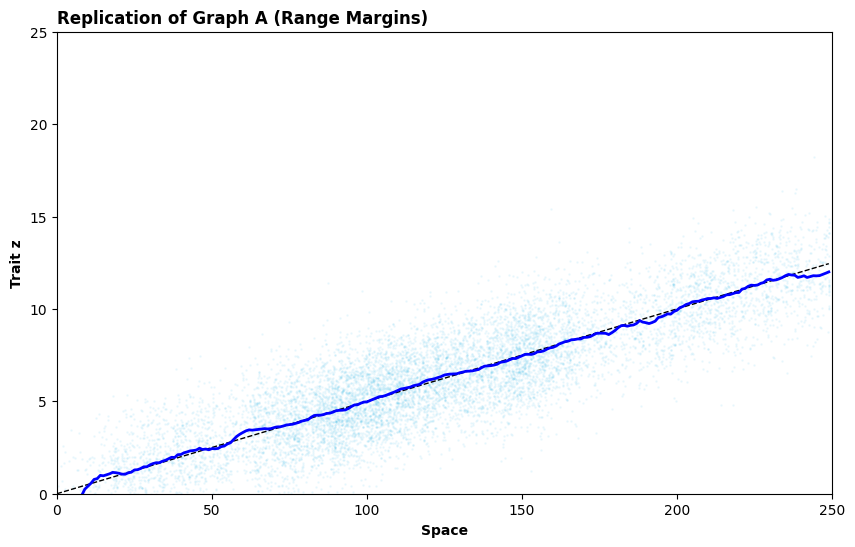

In [9]:
import numpy as np
import matplotlib.pyplot as plt

n_demes = 250
K = 50
generations = 2000
sigma = 3.0
b = 0.05
Vs = 1.5
Vm = 1.0

optimums = b * np.arange(n_demes)

pop_list = []
for x in range (100, 150):
  for _ in range(K):
    pop_list.append([x, optimums[x]])

pop = np.array(pop_list)


for gen in range(generations):
    if len(pop) == 0:
        print(f"Extinct at generation {gen}")
        break

    locs = np.clip(pop[:, 0], 0, n_demes - 1).astype(int)
    fitness = np.exp(-((pop[:, 1] - optimums[locs])**2) / (2 * 5.0))
    pop = pop[np.random.rand(len(pop)) < fitness]

    if len(pop)> 0:
      off_traits = np.tile(pop[:, 1], 2) + np.random.normal(0, np.sqrt(Vm), len(pop) * 2)
      off_locs = np.tile(pop[:, 0], 2)
      pop = np.column_stack((off_locs, off_traits))

    pop[:, 0] += np.random.normal(0, 1.0, len(pop))
    pop[:, 0] = np.clip(pop[:, 0], 0, n_demes - 1)

    if len(pop) > 10000:
          indices = np.random.choice(len(pop), 10000, replace=False)
          pop = pop[indices]

print("Final Pop count:", len(pop))

plt.figure(figsize=(10,6))

if len(pop) > 0:
    plt.scatter(pop[:, 0], pop[:, 1], alpha=0.05, color='#00AEEF', s=1)

plt.plot(range(n_demes), optimums, color='black', linestyle='--', linewidth=1, label="Optimum 0")


active_x, mean_z = [], []
for d in range(n_demes):
    deme_traits = pop[np.abs(pop[:, 0] - d) < 5.0][:, 1]
    if len(deme_traits)>0:
        mean_z.append(np.mean(deme_traits))
        active_x.append(d)

if active_x:
    plt.plot(active_x, mean_z, color='blue', linewidth=2, label="Mean trait z")

plt.xlim(0, 250)
plt.ylim(0, 25)
plt.xlabel('Space', fontweight='bold')
plt.ylabel('Trait z', fontweight='bold')
plt.title('Replication of Graph A (Range Margins)', loc='left', fontweight='bold')
plt.show()


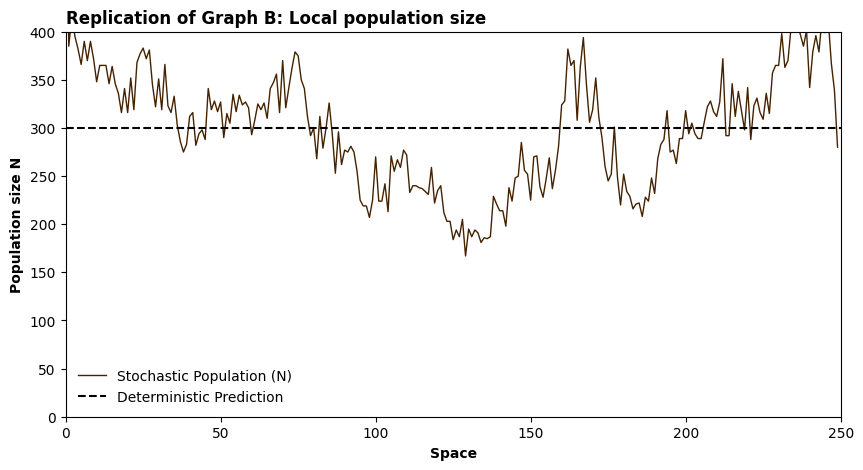

In [28]:
import numpy as np
import matplotlib.pyplot as plt

n_demes = 250
generations = 500
Vs = 5.0
Vm = 0.05
sigma = 1.0
K = 20
max_pop =75000
optimums = np.linspace(0, 25, n_demes)

pop_list = []
for x in range(0, 250):
    for _ in range(K):
       pop_list.append([x, optimums[x]])
pop = np.array(pop_list)

for gen in range(generations):
    if len(pop) == 0: break

    locs = np.clip(pop[:, 0], 0, n_demes - 1).astype(int)
    fitness = np.exp(-((pop[:, 1] - optimums[locs])**2) / (2 * Vs))
    pop = pop[np.random.rand(len(pop)) < fitness]

    if len(pop)> 0:
        off_traits = np.tile(pop[:, 1], 2) + np.random.normal(0, np.sqrt(Vm), len(pop) * 2)
        off_locs = np.tile(pop[:, 0], 2)
        pop = np.column_stack((off_locs, off_traits))

        pop[:, 0] += np.random.normal(0, sigma, len(pop))
        pop[:, 0] = np.clip(pop[:, 0], 0, n_demes - 1)

        if len(pop)> max_pop:
            indices = np.random.choice(len(pop), max_pop, replace=False)
            pop = pop[indices]


counts, bins = np.histogram(pop[:, 0], bins=n_demes, range=(0, n_demes))

plt.figure(figsize =(10, 5))
plt.plot(range(n_demes), counts, color='#442200', linewidth=1, label='Stochastic Population (N)')
plt.axhline(y=300, color='black', linestyle='--', label='Deterministic Prediction')

plt.xlabel('Space', fontweight='bold')
plt.ylabel('Population size N', fontweight='bold')
plt.title('Replication of Graph B: Local population size', loc='left', fontweight='bold')
plt.ylim(0, 400)
plt.xlim(0, 250)
plt.legend(frameon=False)
plt.grid(False)
plt.show()




